In [ ]:
# =========================
# Phase 1.3 - EfficientNetB0 Transfer Learning
# Setup and Paths
# =========================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import gc

# =========================
# Clear Runtime Memory Only
# =========================

tf.keras.backend.clear_session()
gc.collect()

# =========================
# Reproducibility
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# Project Paths
# =========================

PROJECT_DIR = Path("/content/drive/MyDrive/Calorify")
PHASE1_DIR = PROJECT_DIR / "phase1_clean"

SPLIT_DATA_DIR = PHASE1_DIR / "data" / "split"
METADATA_DIR = PHASE1_DIR / "metadata"
RESULTS_DIR = PHASE1_DIR / "results"
MODELS_DIR = PHASE1_DIR / "models"

train_dir = SPLIT_DATA_DIR / "train"
val_dir = SPLIT_DATA_DIR / "val"
test_dir = SPLIT_DATA_DIR / "test"

# EfficientNetB0 specific outputs
EFFICIENTNET_MODEL_PATH = MODELS_DIR / "efficientnetb0_transfer_learning.keras"
EFFICIENTNET_WEIGHTS_PATH = MODELS_DIR / "efficientnetb0_transfer_learning.weights.h5"
EFFICIENTNET_HISTORY_PATH = RESULTS_DIR / "efficientnetb0_history.csv"

# =========================
# Load Class Names
# =========================

class_names_path = METADATA_DIR / "class_names.json"

with open(class_names_path, "r") as f:
    class_names = json.load(f)

NUM_CLASSES = len(class_names)

print("Project directory:", PROJECT_DIR)
print("Phase 1 directory:", PHASE1_DIR)
print("Split data directory:", SPLIT_DATA_DIR)
print("Train directory:", train_dir)
print("Val directory:", val_dir)
print("Test directory:", test_dir)

print("\nClass names:")
print(class_names)

print("\nNumber of classes:", NUM_CLASSES)
print("\nEfficientNetB0 model will be saved to:")
print(EFFICIENTNET_MODEL_PATH)
print("\nEfficientNetB0 weights will be saved to:")
print(EFFICIENTNET_WEIGHTS_PATH)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Calorify
Phase 1 directory: /content/drive/MyDrive/Calorify/phase1_clean
Split data directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split
Train directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/train
Val directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/val
Test directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/test

Class names:
['burger', 'pizza', 'fries', 'pasta', 'rice', 'chicken', 'salad', 'sandwich', 'sushi', 'steak']

Number of classes: 10

EfficientNetB0 model will be saved to:
/content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.keras

EfficientNetB0 weights will be saved to:
/content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.weights.h5


In [ ]:
# =========================
# Cell 2 - Load TensorFlow Datasets + Class Weights
# =========================

import tensorflow as tf
import pandas as pd

# =========================
# Dataset Config
# =========================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# =========================
# Load Prepared Train / Val / Test Split
# =========================

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =========================
# Prefetch for Performance
# =========================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nDatasets loaded successfully.")

# =========================
# Load Class Weights
# =========================

class_weights_path = METADATA_DIR / "class_weights.csv"
class_weight_df = pd.read_csv(class_weights_path)

class_weight = {
    int(row["class_index"]): float(row["class_weight"])
    for _, row in class_weight_df.iterrows()
}

print("\nClass weights loaded from:")
print(class_weights_path)

display(class_weight_df)

print("\nclass_weight dictionary:")
print(class_weight)

Found 3413 files belonging to 10 classes.
Found 731 files belonging to 10 classes.
Found 732 files belonging to 10 classes.

Datasets loaded successfully.

Class weights loaded from:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/class_weights.csv


,class_index,class_name,train_count,class_weight
0,0,burger,350,0.975143
1,1,pizza,350,0.975143
2,2,fries,350,0.975143
3,3,pasta,350,0.975143
4,4,rice,301,1.133887
5,5,chicken,350,0.975143
6,6,salad,350,0.975143
7,7,sandwich,350,0.975143
8,8,sushi,312,1.093910
9,9,steak,350,0.975143



class_weight dictionary:
{0: 0.9751428571428572, 1: 0.9751428571428572, 2: 0.9751428571428572, 3: 0.9751428571428572, 4: 1.1338870431893688, 5: 0.9751428571428572, 6: 0.9751428571428572, 7: 0.9751428571428572, 8: 1.0939102564102563, 9: 0.9751428571428572}


Data augmentation layer created successfully.


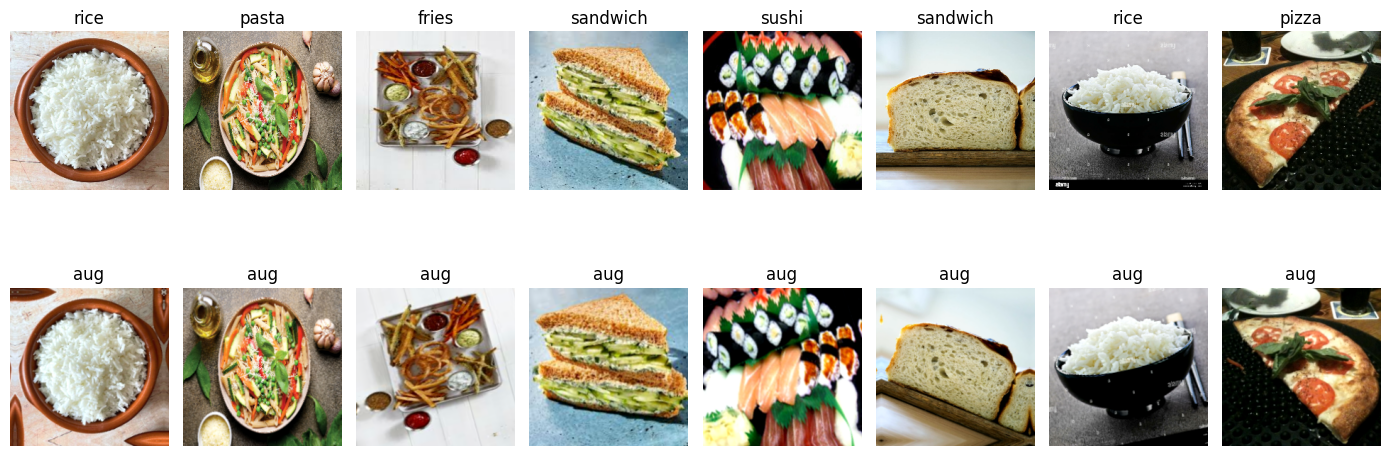

Sample image batch shape: (8, 224, 224, 3)
Sample label batch shape: (8, 10)


In [ ]:
# =========================
# Cell 3 - Data Augmentation Preview for EfficientNetB0
# =========================

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data Augmentation Layer
# =========================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="efficientnetb0_data_augmentation")

print("Data augmentation layer created successfully.")

# =========================
# Preview Original vs Augmented Images
# =========================

for images, labels in train_ds.take(1):
    sample_images = images[:8]
    sample_labels = labels[:8]
    augmented_images = data_augmentation(sample_images, training=True)

plt.figure(figsize=(14, 6))

for i in range(8):
    label_index = np.argmax(sample_labels[i].numpy())
    label_name = class_names[label_index]

    # Original image
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(label_name)
    plt.axis("off")

    # Augmented image
    ax = plt.subplot(2, 8, i + 9)
    aug_img = augmented_images[i].numpy()
    aug_img = np.clip(aug_img, 0, 255).astype("uint8")
    plt.imshow(aug_img)
    plt.title("aug")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample image batch shape:", sample_images.shape)
print("Sample label batch shape:", sample_labels.shape)

In [ ]:
# =========================
# Cell 4 - Build EfficientNetB0 Transfer Learning Model
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

# =========================
# EfficientNetB0 Config
# =========================

IMAGE_SHAPE = (224, 224, 3)
LEARNING_RATE_EFFICIENTNET = 1e-3
EPOCHS_EFFICIENTNET = 15

print("Building EfficientNetB0 transfer learning model...")
print("Number of classes:", NUM_CLASSES)

# =========================
# Load Pretrained Base Model
# =========================

base_model = EfficientNetB0(
    input_shape=IMAGE_SHAPE,
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers first
base_model.trainable = False

print("EfficientNetB0 base model loaded with ImageNet weights.")
print("Base model trainable:", base_model.trainable)

# =========================
# Build Full Model
# =========================

inputs = layers.Input(shape=IMAGE_SHAPE, name="input_image")

# Data augmentation only active during training
x = data_augmentation(inputs)

# EfficientNetB0 feature extractor
# No manual Rescaling or Lambda preprocessing needed here
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.BatchNormalization(name="head_batch_norm")(x)
x = layers.Dropout(0.4, name="head_dropout")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="food_class_output"
)(x)

efficientnet_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_TransferLearning"
)

# =========================
# Compile Model
# =========================

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_EFFICIENTNET),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

Building EfficientNetB0 transfer learning model...
Number of classes: 10
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
EfficientNetB0 base model loaded with ImageNet weights.
Base model trainable: False


Model: "EfficientNetB0_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0_data_augmentati… │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_class_output (Dense)       │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,381,101 (16.71 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [ ]:
# =========================
# Cell 5 - Train EfficientNetB0 Frozen Base
# =========================

import pandas as pd
import tensorflow as tf

# =========================
# EfficientNetB0 Callbacks
# =========================

efficientnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(EFFICIENTNET_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# Train EfficientNetB0 Head
# =========================

efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_EFFICIENTNET,
    callbacks=efficientnet_callbacks,
    class_weight=class_weight
)

# =========================
# Save Training History
# =========================

efficientnet_history_df = pd.DataFrame(efficientnet_history.history)
efficientnet_history_df.to_csv(EFFICIENTNET_HISTORY_PATH, index=False)

print("EfficientNetB0 frozen-base training completed.")
print("EfficientNetB0 model saved to:")
print(EFFICIENTNET_MODEL_PATH)

print("\nEfficientNetB0 history saved to:")
print(EFFICIENTNET_HISTORY_PATH)

display(efficientnet_history_df)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5917 - loss: 1.3287
Epoch 1: val_loss improved from None to 0.55886, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1035s 10s/step - accuracy: 0.7120 - loss: 0.9264 - val_accuracy: 0.8345 - val_loss: 0.5589 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8368 - loss: 0.4734
Epoch 2: val_loss improved from 0.55886 to 0.46609, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 411s 4s/step - accuracy: 0.8441 - loss: 0.4774 - val_accuracy: 0.8564 - val_loss: 0.4661 -

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.711984,0.926374,0.834473,0.558856,0.0010
1,0.844125,0.477384,0.856361,0.466085,0.0010
2,0.890712,0.341019,0.856361,0.468054,0.0010
3,0.909464,0.278207,0.867305,0.451820,0.0010
4,0.918840,0.253271,0.857729,0.484395,0.0010
5,0.924407,0.226153,0.871409,0.485752,0.0010
6,0.945210,0.172066,0.879617,0.453594,0.0005
7,0.947846,0.157305,0.874145,0.470192,0.0005


In [ ]:
# =========================
# Cell 6 - Evaluate EfficientNetB0 on Test Set
# =========================

test_loss, test_accuracy = efficientnet_model.evaluate(test_ds)

print("EfficientNetB0 Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 197s 8s/step - accuracy: 0.8934 - loss: 0.3992
EfficientNetB0 Test Results
Test Loss: 0.3992
Test Accuracy: 0.8934


In [ ]:
# =========================
# Save EfficientNetB0 Weights Safely
# =========================

efficientnet_model.save_weights(EFFICIENTNET_WEIGHTS_PATH)

print("EfficientNetB0 weights saved safely to:")
print(EFFICIENTNET_WEIGHTS_PATH)

EfficientNetB0 weights saved safely to:
/content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.weights.h5


EfficientNetB0 training history loaded from:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.711984,0.926374,0.834473,0.558856,0.0010
1,0.844125,0.477384,0.856361,0.466085,0.0010
2,0.890712,0.341019,0.856361,0.468054,0.0010
3,0.909464,0.278207,0.867305,0.451820,0.0010
4,0.918840,0.253271,0.857729,0.484395,0.0010
5,0.924407,0.226153,0.871409,0.485752,0.0010
6,0.945210,0.172066,0.879617,0.453594,0.0005
7,0.947846,0.157305,0.874145,0.470192,0.0005


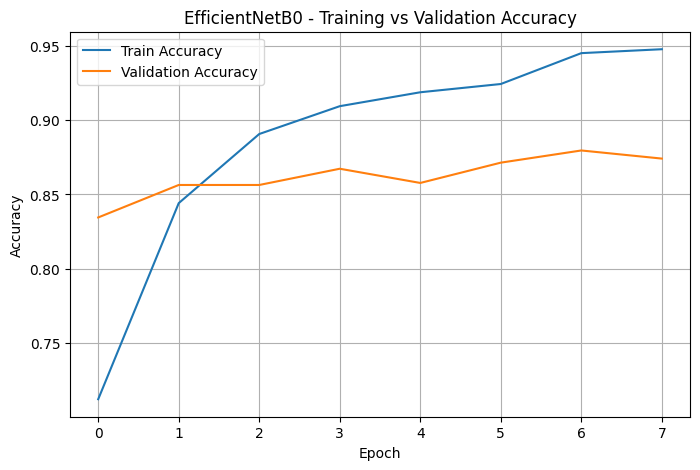

Accuracy curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_accuracy_curve.png


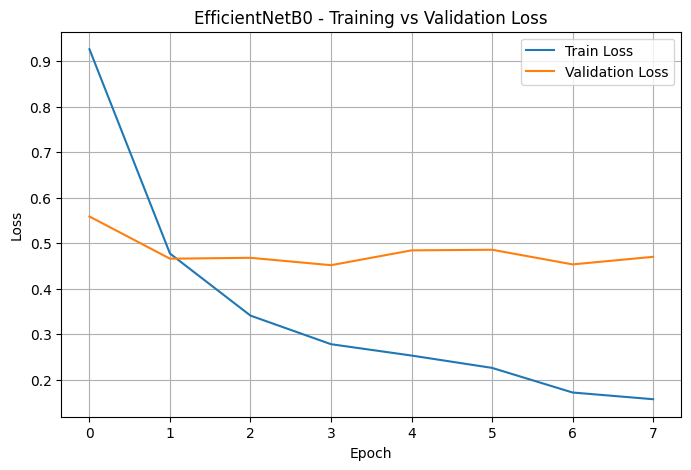

Loss curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_loss_curve.png


In [ ]:
# =========================
# Cell 7 - EfficientNetB0 Training Curves
# =========================

import pandas as pd
import matplotlib.pyplot as plt

# Load EfficientNetB0 history
efficientnet_history_df = pd.read_csv(EFFICIENTNET_HISTORY_PATH)

print("EfficientNetB0 training history loaded from:")
print(EFFICIENTNET_HISTORY_PATH)

display(efficientnet_history_df)

# =========================
# Accuracy Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(efficientnet_history_df["accuracy"], label="Train Accuracy")
plt.plot(efficientnet_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

efficientnet_accuracy_curve_path = RESULTS_DIR / "efficientnetb0_accuracy_curve.png"
plt.savefig(efficientnet_accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved to:")
print(efficientnet_accuracy_curve_path)

# =========================
# Loss Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(efficientnet_history_df["loss"], label="Train Loss")
plt.plot(efficientnet_history_df["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

efficientnet_loss_curve_path = RESULTS_DIR / "efficientnetb0_loss_curve.png"
plt.savefig(efficientnet_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved to:")
print(efficientnet_loss_curve_path)

Using EfficientNetB0 model currently in memory with best restored weights.
EfficientNetB0 classification report saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_classification_report.csv


,precision,recall,f1-score,support
burger,0.918919,0.906667,0.912752,75.000000
pizza,0.900000,0.960000,0.929032,75.000000
fries,0.959459,0.946667,0.953020,75.000000
pasta,0.910448,0.813333,0.859155,75.000000
rice,0.906250,0.892308,0.899225,65.000000
chicken,0.844156,0.866667,0.855263,75.000000
salad,0.909091,0.933333,0.921053,75.000000
sandwich,0.898551,0.826667,0.861111,75.000000
sushi,0.805195,0.925373,0.861111,67.000000
steak,0.890411,0.866667,0.878378,75.000000


EfficientNetB0 confusion matrix CSV saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_confusion_matrix.csv


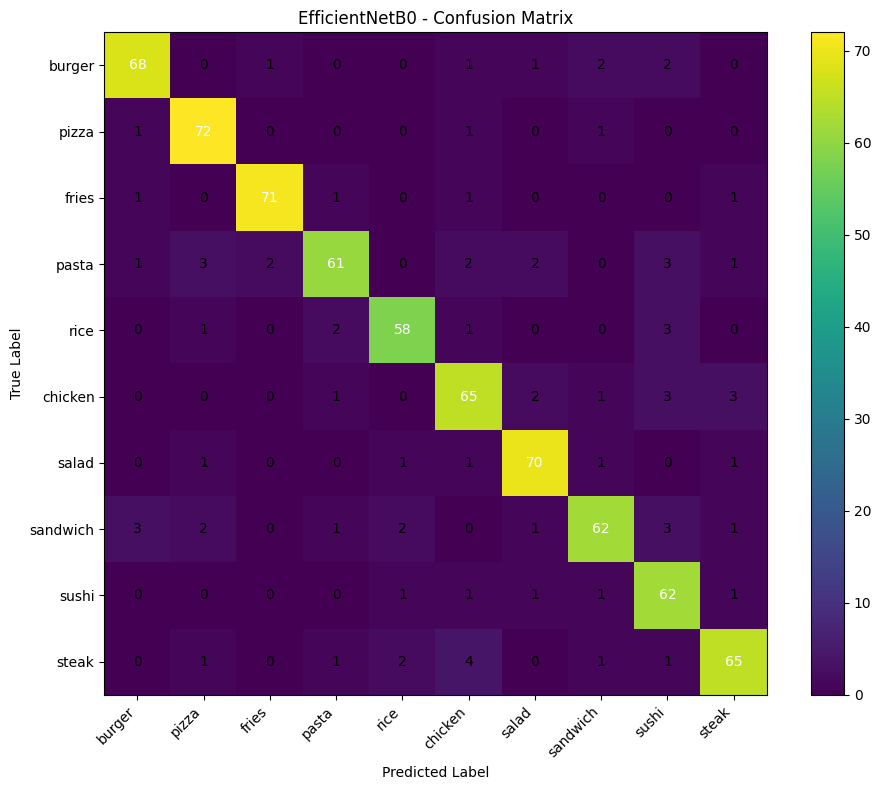

EfficientNetB0 confusion matrix image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_confusion_matrix.png


In [ ]:
# =========================
# Cell 8 - EfficientNetB0 Classification Report + Confusion Matrix
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# Use current EfficientNetB0 model in memory
# It restored best weights using EarlyStopping
best_efficientnet_model = efficientnet_model

print("Using EfficientNetB0 model currently in memory with best restored weights.")

# =========================
# Collect True Labels and Predictions
# =========================

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_efficientnet_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)

    y_true.extend(true_indices)
    y_pred.extend(pred_indices)
    y_prob.extend(np.max(probabilities, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# =========================
# Classification Report
# =========================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

efficientnet_report_df = pd.DataFrame(report_dict).transpose()

efficientnet_report_path = RESULTS_DIR / "efficientnetb0_classification_report.csv"
efficientnet_report_df.to_csv(efficientnet_report_path)

print("EfficientNetB0 classification report saved to:")
print(efficientnet_report_path)

display(efficientnet_report_df)

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

efficientnet_cm_csv_path = RESULTS_DIR / "efficientnetb0_confusion_matrix.csv"
cm_df.to_csv(efficientnet_cm_csv_path)

print("EfficientNetB0 confusion matrix CSV saved to:")
print(efficientnet_cm_csv_path)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("EfficientNetB0 - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()

efficientnet_cm_png_path = RESULTS_DIR / "efficientnetb0_confusion_matrix.png"
plt.savefig(efficientnet_cm_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("EfficientNetB0 confusion matrix image saved to:")
print(efficientnet_cm_png_path)

EfficientNetB0 wrong predictions saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_wrong_predictions.csv

Number of wrong predictions: 78
Number of correct predictions: 654


,image_path,true_class,predicted_class,confidence,is_correct
0,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sandwich,0.534725,False
1,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.566723,False
2,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,salad,0.436505,False
3,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,fries,0.555194,False
4,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,chicken,0.656601,False
5,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.375759,False
6,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sandwich,0.961965,False
7,/content/drive/MyDrive/Calorify/phase1_clean/d...,pizza,chicken,0.547345,False
8,/content/drive/MyDrive/Calorify/phase1_clean/d...,pizza,sandwich,0.331742,False
9,/content/drive/MyDrive/Calorify/phase1_clean/d...,pizza,burger,0.423856,False


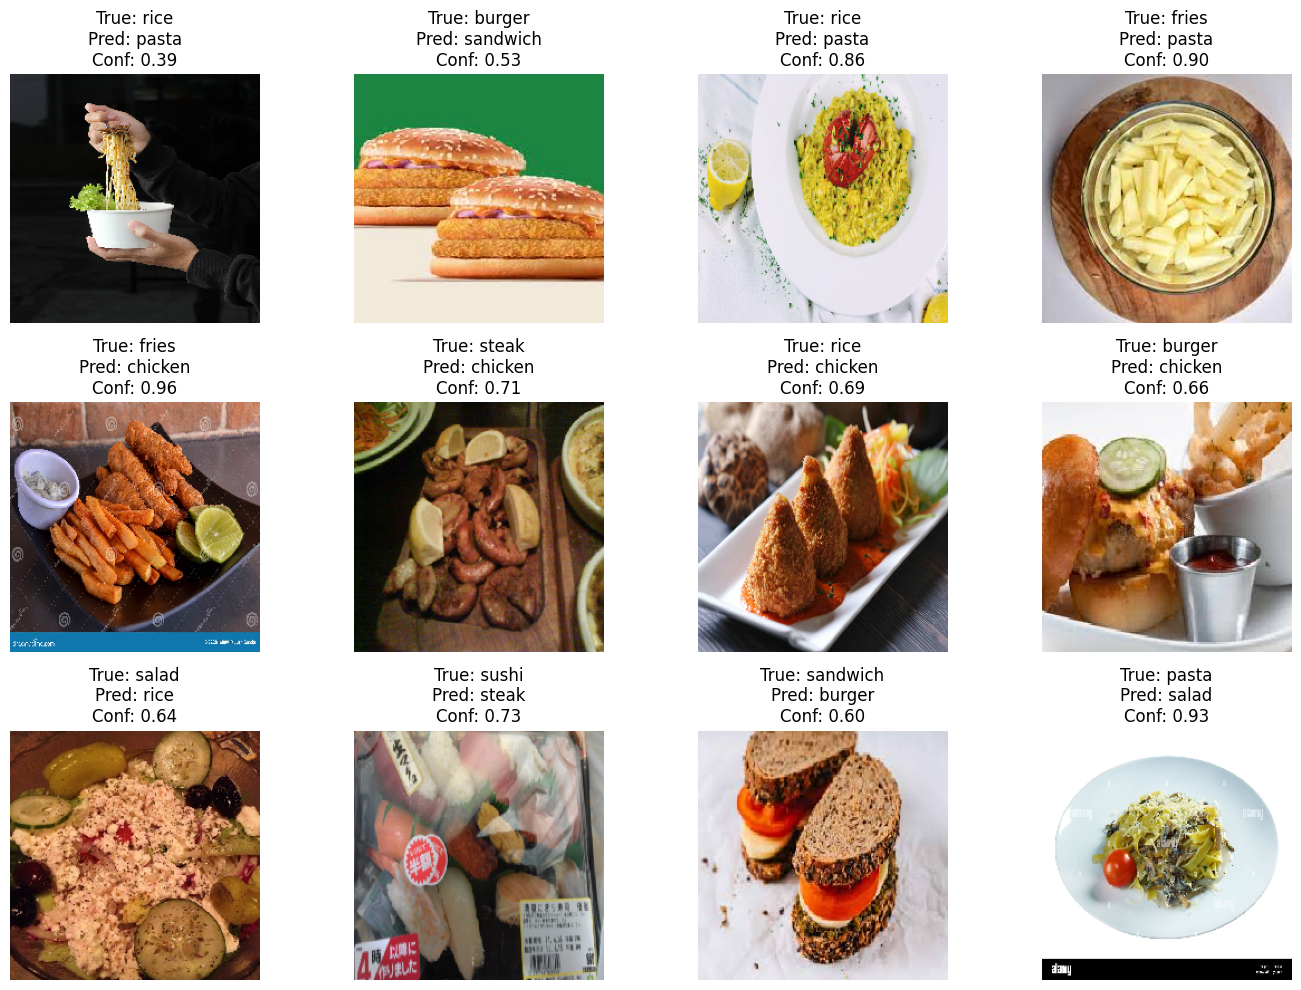

EfficientNetB0 wrong prediction samples image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_wrong_prediction_samples.png


In [ ]:
# =========================
# Cell 9 - EfficientNetB0 Wrong Prediction Samples
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use current EfficientNetB0 model in memory
best_efficientnet_model = efficientnet_model

wrong_records = []
correct_records = []

# Collect file paths from test directory in the same order as test_ds
test_image_paths = []

for class_name in class_names:
    class_dir = test_dir / class_name
    class_files = sorted([
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
    ])
    test_image_paths.extend(class_files)

sample_index = 0

for images, labels in test_ds:
    probabilities = best_efficientnet_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    for i in range(len(images)):
        true_class = class_names[true_indices[i]]
        predicted_class = class_names[pred_indices[i]]
        confidence = float(confidences[i])

        image_path = str(test_image_paths[sample_index]) if sample_index < len(test_image_paths) else ""

        record = {
            "image_path": image_path,
            "true_class": true_class,
            "predicted_class": predicted_class,
            "confidence": confidence,
            "is_correct": true_class == predicted_class
        }

        if true_class == predicted_class:
            correct_records.append(record)
        else:
            wrong_records.append(record)

        sample_index += 1

efficientnet_wrong_df = pd.DataFrame(wrong_records)
efficientnet_correct_df = pd.DataFrame(correct_records)

efficientnet_wrong_predictions_path = RESULTS_DIR / "efficientnetb0_wrong_predictions.csv"
efficientnet_wrong_df.to_csv(efficientnet_wrong_predictions_path, index=False)

print("EfficientNetB0 wrong predictions saved to:")
print(efficientnet_wrong_predictions_path)

print("\nNumber of wrong predictions:", len(efficientnet_wrong_df))
print("Number of correct predictions:", len(efficientnet_correct_df))

display(efficientnet_wrong_df.head(20))

# =========================
# Show Sample Wrong Predictions
# =========================

sample_wrong_df = efficientnet_wrong_df.sample(
    n=min(12, len(efficientnet_wrong_df)),
    random_state=42
).reset_index(drop=True)

plt.figure(figsize=(14, 10))

for i, row in sample_wrong_df.iterrows():
    img_path = row["image_path"]

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img_array)
    plt.title(
        f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()

efficientnet_wrong_samples_path = RESULTS_DIR / "efficientnetb0_wrong_prediction_samples.png"
plt.savefig(efficientnet_wrong_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print("EfficientNetB0 wrong prediction samples image saved to:")
print(efficientnet_wrong_samples_path)

In [ ]:
# =========================
# Cell 10 - Save EfficientNetB0 Final Summary
# =========================

import pandas as pd

efficientnet_summary = {
    "model_name": "EfficientNetB0 Transfer Learning",
    "model_type": "Pretrained CNN / Transfer Learning",
    "training_strategy": "Frozen EfficientNetB0 base + custom classification head",
    "weights_file": str(EFFICIENTNET_WEIGHTS_PATH),
    "history_file": str(EFFICIENTNET_HISTORY_PATH),

    # Test results
    "test_accuracy": 0.8934,
    "test_loss": 0.3992,

    # Validation results
    "best_validation_accuracy": 0.879617,
    "best_validation_loss": 0.451820,
    "best_val_loss_epoch": 4,
    "highest_val_accuracy_epoch": 7,

    # Classification report
    "macro_f1_score": 0.893010,
    "weighted_f1_score": 0.893274,

    # Error analysis
    "correct_predictions": 654,
    "wrong_predictions": 78,

    "status": "Completed",
    "notes": (
        "EfficientNetB0 achieved the best performance so far among the tested visual models. "
        "It outperformed both the Custom CNN baseline and MobileNetV2 transfer learning model. "
        "The confusion matrix showed strong diagonal performance across most food classes. "
        "Remaining errors mainly occurred in visually similar or noisy samples such as "
        "burger/sandwich, rice/pasta, fries/chicken, steak/chicken, and pasta/sushi. "
        "The wrong prediction analysis suggests that many errors are caused by dataset ambiguity, "
        "mixed dishes, unusual image angles, or label noise rather than complete model failure."
    )
}

efficientnet_summary_df = pd.DataFrame([efficientnet_summary])

efficientnet_summary_csv_path = RESULTS_DIR / "efficientnetb0_final_summary.csv"
efficientnet_summary_txt_path = RESULTS_DIR / "efficientnetb0_final_summary.txt"

efficientnet_summary_df.to_csv(efficientnet_summary_csv_path, index=False)

with open(efficientnet_summary_txt_path, "w", encoding="utf-8") as f:
    for key, value in efficientnet_summary.items():
        f.write(f"{key}: {value}\n")

print("EfficientNetB0 final summary saved to:")
print(efficientnet_summary_csv_path)
print(efficientnet_summary_txt_path)

display(efficientnet_summary_df)

EfficientNetB0 final summary saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_final_summary.csv
/content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_final_summary.txt


,model_name,model_type,training_strategy,weights_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_loss,best_val_loss_epoch,highest_val_accuracy_epoch,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,status,notes
0,EfficientNetB0 Transfer Learning,Pretrained CNN / Transfer Learning,Frozen EfficientNetB0 base + custom classifica...,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.8934,0.3992,0.879617,0.45182,4,7,0.89301,0.893274,654,78,Completed,EfficientNetB0 achieved the best performance s...


In [ ]:
# Final Summary — EfficientNetB0 Transfer Learning

#In this notebook, EfficientNetB0 was used as the third Phase 1 image classification model after the Custom CNN baseline and MobileNetV2 transfer learning model. The same prepared train, validation, and test split was used to ensure fair comparison across all visual models.

#EfficientNetB0 was loaded with pretrained ImageNet weights and used as a frozen feature extractor. A custom classification head was added on top of the pretrained base model for the 10 food classes.

#The model achieved:

#- Test Accuracy: 89.34%
#- Test Loss: 0.3992
#- Best Validation Loss: 0.4518
#- Highest Validation Accuracy: 87.96%
#- Macro F1-score: 89.30%
#- Weighted F1-score: 89.33%
#- Correct Predictions: 654
#- Wrong Predictions: 78

#Compared with the previous models, EfficientNetB0 achieved the best performance so far. The Custom CNN achieved around 50.55% test accuracy, MobileNetV2 achieved 85.52%, while EfficientNetB0 achieved 89.34%.

#The confusion matrix showed strong diagonal performance across most classes, especially fries, pizza, salad, burger, and rice. Remaining errors mainly occurred between visually similar or noisy classes such as burger/sandwich, rice/pasta, fries/chicken, steak/chicken, and pasta/sushi.

#Overall, EfficientNetB0 is currently the best visual model tested in Phase 1.

In [1]:
# Check whether the trained EfficientNetB0 model is currently available in memory

print("efficientnet_model exists:", "efficientnet_model" in globals())
print("class_names exists:", "class_names" in globals())
print("test_ds exists:", "test_ds" in globals())

efficientnet_model exists: False
class_names exists: False
test_ds exists: False
